# NeuroGPT on BNCI2014001 (BCI IV-2a) - full LOSO + K-min, 3 heads

Pivot from MIRepNet to **NeuroGPT** (Cui et al., "Neuro-GPT: Towards a Foundation
Model for EEG", ISBI 2024; `wenhui0206/NeuroGPT`). Same full 9-subject
leave-one-subject-out + K-trial calibration protocol as the MIRepNet/BNCI
notebook, but now comparing **three** heads on the frozen NeuroGPT encoder
feature: a **linear probe**, a **simple MLP** (new baseline), and the **2-stage
convex-NN head**.

NeuroGPT was pretrained on the **TUH** EEG corpus (not motor imagery), so
BNCI2014001 is a genuine cross-dataset downstream eval - and BCI IV-2a is
NeuroGPT's own benchmark. Following the paper's best downstream setting
(`--ft-only-encoder`), we use the **encoder only** (the GPT decoder is dropped)
and probe its frozen representation.

## NeuroGPT input format (verified against the repo + HF weights)

| field | value | source |
|---|---|---|
| loader | **MOABB** `MotorImagery` (the repo's dataset names are MOABB classes) | - |
| channels | first **22 EEG channels** (BCI IV-2a GDF order == MOABB order) | `downstream_dataset.py` |
| channel remap | **`P` (22x22)** matrix `inputs/tMatrix_value.npy` maps the montage to the TUH pretraining montage (`map2pret`) | `downstream_dataset.py` |
| band-pass | **none** for the BCI-2a downstream (the bandpass call is commented out) -> broadband; here MOABB fmin=0.5, fmax=100 | `downstream_dataset.py` |
| sampling rate | **250 Hz** | `downstream_dataset.py` |
| window | 4 s -> **1000 samples** (MOABB interval [2,6]) | `finetune.sh` (num_chunks=2 x chunk_len=500) |
| normalization | per-channel **z-score over time** | `batcher/base.py:normalize` |
| chunking | **2 chunks x 500 samples, overlap 0** -> model input (B, 2, 22, 500) | `finetune.sh`, `batcher/base.py:split_chunks` |
| encoder | EEG-Conformer: temporal conv (k=25) -> spatial conv over 22 ch -> avg-pool -> 6-layer transformer (emb 40, 10 heads) | `conformer_braindecode.py` |
| feature | transformer output (B, 2, 27, 40), **mean-pooled over tokens, 2 chunks concatenated -> 80-d** (the pretrained fc/head is random-init in decoding mode, so we don't use it) | this notebook |
| weights | `wenhuic/Neuro-GPT` `pretrained_model/pytorch_model.bin`; 107 `encoder.*` tensors load exactly | HF |

Frozen NeuroGPT features are only modestly discriminative here (the paper
*fine-tunes* the encoder); the probe numbers should be read in that light.


## 0. Config

In [1]:
from __future__ import annotations

import sys, os, json, time, warnings
from pathlib import Path

import numpy as np
import torch
warnings.filterwarnings("ignore")

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
CLD_DIR = REPO_ROOT / "vendor" / "CLD"
NEUROGPT_VENDOR = REPO_ROOT / "vendor" / "NeuroGPT"
TMATRIX_PATH = REPO_ROOT / "inputs" / "tMatrix_value.npy"
FEAT_CACHE_DIR = REPO_ROOT / "data" / "cache" / "neurogpt_bnci2014001_feats"
assert CLD_DIR.exists(), f"missing CLD vendor dir: {CLD_DIR}"
assert (NEUROGPT_VENDOR / "neurogpt_conformer.py").exists(), f"missing vendored NeuroGPT encoder in {NEUROGPT_VENDOR}"
assert TMATRIX_PATH.exists(), f"missing channel-remap matrix {TMATRIX_PATH}"

# --- protocol (same as the MIRepNet/BNCI notebook) ---
K_BUDGETS      = (0, 1, 2, 5, 10, 20, 30)   # trials per class; K=0 = pure LOSO
EVAL_PER_CLASS = 40                          # fixed held-out eval trials per class
SEED           = 0

# --- dataset / NeuroGPT preprocessing spec ---
N_CLASSES   = 4
N_CHANS     = 22                             # native BCI IV-2a EEG channels (-> P -> TUH montage)
TARGET_FS   = 250
BANDPASS    = (0.5, 100.0)                   # broadband: NeuroGPT does not MI-bandpass the downstream
CHUNK_LEN   = 500
NUM_CHUNKS  = 2
CHUNK_OVLP  = 0
TRIAL_SAMPLES = CHUNK_LEN * NUM_CHUNKS       # 1000 (MOABB interval [2,6])
ENC_EMB     = 40                             # conformer n_filters_time
ENC_DEPTH   = 6
ENC_HEADS   = 10
FEATURE_POOL = "mean"                        # mean-pool transformer tokens per chunk, concat chunks
FEATURE_DIM = ENC_EMB * NUM_CHUNKS           # 80
LABEL_MAP = {"left_hand": 0, "right_hand": 1, "feet": 2, "tongue": 3}

NEUROGPT_DEVICE = "cpu"

# --- ConvexNN head hparams (shared with the other notebooks) ---
CVX_N_NEURONS  = 16
CVX_BETA       = 1.0e-3
CVX_RHO        = 0.1
CVX_ADMM_ITERS = 8
CVX_PCG_ITERS  = 32
CVX_RANK       = 20
STAGE2_ADMM_ITERS = 4
STAGE2_TARGET_MASS = 0.35
STAGE2_WARM_START_DUAL = False

# --- Linear probe hparams ---
LINPROBE_C = 1.0
LINPROBE_MAX_ITER = 2000
LINPROBE_TARGET_MASS = STAGE2_TARGET_MASS

# --- Simple MLP baseline hparams ---
MLP_HIDDEN  = 128
MLP_DROPOUT = 0.3
MLP_EPOCHS  = 60
MLP_LR      = 1.0e-3
MLP_WD      = 1.0e-4
MLP_BATCH   = 64
MLP_DEVICE  = "cpu"          # tiny 80-d MLP; CPU is fast and avoids any MPS instability
MLP_TARGET_MASS = STAGE2_TARGET_MASS

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"torch device={DEVICE}  neurogpt_device={NEUROGPT_DEVICE}  mlp_device={MLP_DEVICE}  |  repo={REPO_ROOT}")


torch device=mps  neurogpt_device=cpu  mlp_device=cpu  |  repo=/Users/williamtan/Projects/cs229/etm_clf


## 1. Load BNCI2014001 via MOABB (22 ch, 250 Hz, broadband, interval [2,6])

In [2]:
import moabb
from moabb.paradigms import MotorImagery
try:
    from moabb.datasets import BNCI2014_001 as _BNCI
except Exception:
    from moabb.datasets import BNCI2014001 as _BNCI

DATASET = _BNCI()
PARADIGM = MotorImagery(n_classes=N_CLASSES, fmin=BANDPASS[0], fmax=BANDPASS[1], resample=float(TARGET_FS))
SUBJECTS = list(DATASET.subject_list)
P_REMAP = np.load(TMATRIX_PATH)   # (22, 22) maps native montage -> TUH pretraining montage
assert P_REMAP.shape == (N_CHANS, N_CHANS), P_REMAP.shape
print(f"dataset={DATASET.code}  subjects={SUBJECTS}  P_remap={P_REMAP.shape}")

def get_subject_raw(subj: int):
    """Return (X_native (n, 22, 1000), y_int (n,)) for one subject (broadband, 250 Hz)."""
    epochs, y, _meta = PARADIGM.get_data(dataset=DATASET, subjects=[subj], return_epochs=True)
    X = epochs.get_data(copy=False).astype(np.float64)[:, :, :TRIAL_SAMPLES]
    yi = np.asarray([LABEL_MAP[str(v)] for v in y], dtype=np.int64)
    return X, yi


Choosing from all possible events


dataset=BNCI2014-001  subjects=[1, 2, 3, 4, 5, 6, 7, 8, 9]  P_remap=(22, 22)


## 2. NeuroGPT encoder feature extractor (P-remap -> z-score -> 2x500 chunks -> Conformer -> 80-d)

In [3]:
if str(NEUROGPT_VENDOR) not in sys.path:
    sys.path.insert(0, str(NEUROGPT_VENDOR))
from neurogpt_conformer import EEGConformer
from huggingface_hub import hf_hub_download

def build_neurogpt_encoder():
    enc = EEGConformer(n_chans=N_CHANS, n_times=CHUNK_LEN, att_depth=ENC_DEPTH,
                       att_heads=ENC_HEADS, n_filters_time=ENC_EMB, is_decoding_mode=False)
    try:
        ckpt = hf_hub_download(repo_id="wenhuic/Neuro-GPT", filename="pretrained_model/pytorch_model.bin")
        sd = torch.load(ckpt, map_location="cpu", weights_only=True)
        enc_sd = {k[len("encoder."):]: v for k, v in sd.items() if k.startswith("encoder.")}
        res = enc.load_state_dict(enc_sd, strict=False)
        print(f"NeuroGPT encoder: loaded {len(enc_sd)} tensors (missing={len(res.missing_keys)}, unexpected={len(res.unexpected_keys)})")
    except Exception as e:
        warnings.warn(f"NeuroGPT pretrained load failed ({type(e).__name__}: {e}); using random init.")
    enc.eval()
    for p in enc.parameters():
        p.requires_grad_(False)
    return enc.to(NEUROGPT_DEVICE)

def _format_chunks(X_native: np.ndarray) -> np.ndarray:
    """NeuroGPT format: P-remap to TUH montage -> per-channel z-score over time ->
    NUM_CHUNKS chunks of CHUNK_LEN. Returns (n, NUM_CHUNKS, 22, CHUNK_LEN)."""
    Xp = np.einsum("ij,njt->nit", P_REMAP, X_native)                 # map2pret
    Xn = (Xp - Xp.mean(-1, keepdims=True)) / (Xp.std(-1, keepdims=True) + 1e-25)
    chunks = []
    start = 0
    for _ in range(NUM_CHUNKS):
        chunks.append(Xn[:, :, start:start + CHUNK_LEN])
        start += CHUNK_LEN - CHUNK_OVLP
    return np.stack(chunks, axis=1).astype(np.float32)

@torch.no_grad()
def encode_subject(enc, X_native: np.ndarray, batch_size: int = 64) -> np.ndarray:
    """Frozen NeuroGPT encoder feature: mean-pool transformer tokens per chunk,
    concat the NUM_CHUNKS chunks -> FEATURE_DIM (80)."""
    chunks = _format_chunks(X_native)
    feats = []
    for i in range(0, len(chunks), batch_size):
        xb = torch.from_numpy(chunks[i:i + batch_size]).to(NEUROGPT_DEVICE)
        out = enc(xb)                                  # (b*NUM_CHUNKS, seq, ENC_EMB)
        bc, seq, d = out.shape
        out = out.view(bc // NUM_CHUNKS, NUM_CHUNKS, seq, d)
        pooled = out.mean(axis=2).reshape(out.shape[0], -1)   # (b, NUM_CHUNKS*ENC_EMB)
        feats.append(pooled.detach().cpu().numpy().astype(np.float32))
    return np.concatenate(feats, axis=0) if feats else np.zeros((0, FEATURE_DIM), np.float32)


## 3. Convex two-layer ReLU MLP head with warm-startable ADMM (backbone-agnostic)

In [4]:
if str(CLD_DIR) not in sys.path:
    sys.path.insert(0, str(CLD_DIR))
import jax
import jax.numpy as jnp
from cld.models.cvx_relu_mlp import CVX_ReLU_MLP
from cld.optimizers.pcg import pcg
from cld.preconditioner.nystrom import Nys_Precond, rand_nys_appx
from cld.utils.proximal_utils import batch_proxl2_tensor
from sklearn.preprocessing import StandardScaler

def admm_warm(model, admm_params, u_init=None, v_init=None, lam_init=None):
    """Inlined ADMM with optional warm-start on (u, v, lam).

    (s, nu) are always re-zeroed since their shape depends on n_samples.
    Stores final (u, v, s, lam, nu, theta1, theta2) on the model.
    """
    rank        = admm_params["rank"]
    beta        = admm_params["beta"]
    gamma_ratio = admm_params["gamma_ratio"]
    admm_iters  = admm_params["admm_iters"]
    pcg_iters   = admm_params["pcg_iters"]

    n, d = model.X.shape
    Y = jax.nn.one_hot(model.y, model.n_classes)

    weight_shape = (model.n_classes, 2, d, model.P_S)
    sample_shape = (model.n_classes, 2, n, model.P_S)

    u   = jnp.asarray(u_init)   if u_init   is not None else jnp.zeros(weight_shape)
    v   = jnp.asarray(v_init)   if v_init   is not None else jnp.zeros(weight_shape)
    lam = jnp.asarray(lam_init) if lam_init is not None else jnp.zeros(weight_shape)
    s   = jnp.zeros(sample_shape)
    nu  = jnp.zeros(sample_shape)

    # Sanity: warm-start tensors must match the new feature/neuron dims.
    for name, arr in (("u_init", u), ("v_init", v), ("lam_init", lam)):
        if arr.shape != weight_shape:
            raise ValueError(f"{name} shape {arr.shape} != expected {weight_shape}")

    U, S, model.seed = rand_nys_appx(model, rank, model.seed)
    Mnys = Nys_Precond(U, S, d, model.rho, model.P_S)
    b_1 = model.batch_rmatvec_F(Y.T) / model.rho

    for _ in range(admm_iters):
        # u update via PCG
        b = b_1 + v - lam + model.batch_rmatvec_G(s - nu)
        u, _, _ = pcg(b, model, Mnys, pcg_iters)
        # v update (group-lasso prox)
        v = v.at[:, 0, :].set(batch_proxl2_tensor(u[:, 0, :] + lam[:, 0, :], beta=beta, gamma=1 / model.rho))
        v = v.at[:, 1, :].set(batch_proxl2_tensor(u[:, 1, :] + lam[:, 1, :], beta=beta, gamma=1 / model.rho))
        # s update (ReLU-cone projection)
        Gu = model.batch_matvec_G(u)
        s = jax.nn.relu(Gu + nu)
        # dual updates
        lam += (u - v) * gamma_ratio
        nu  += (Gu - s) * gamma_ratio

    model.u, model.v, model.s, model.lam, model.nu = u, v, s, lam, nu
    W1, w2 = model.get_ncvx_weights(v)
    model.theta1, model.theta2 = W1, w2
    return u, v, s, lam, nu

def fit_stage1_source(X: np.ndarray, y: np.ndarray, n_classes: int = 4, beta: float = CVX_BETA):
    """Stage 1: cold ADMM on the source pool."""
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X).astype(np.float32)
    m = CVX_ReLU_MLP(
        jnp.asarray(Xs), jnp.asarray(y.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=beta, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),
    )
    m.init_model()
    admm_warm(
        m,
        dict(rank=CVX_RANK, beta=beta, gamma_ratio=1.0,
             admm_iters=CVX_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS, check_opt=False),
    )
    return m, scaler

def fit_stage2_target_only_warm(
    Xc: np.ndarray,
    yc: np.ndarray,
    src_model,
    src_scaler,
    n_classes: int = 4,
    beta: float = CVX_BETA,
):
    """Diagnostic only: solve the new convex problem on calibration trials alone.

    This is the experiment that produced the early-K accuracy drop. Warm start is
    only an ADMM initializer; it is not a source prior once the solve moves.
    """
    Xc_s = src_scaler.transform(Xc.astype(np.float32))
    m = CVX_ReLU_MLP(
        jnp.asarray(Xc_s), jnp.asarray(yc.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=beta, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),  # same random hyperplanes
    )
    m.init_model()
    admm_warm(
        m,
        dict(rank=CVX_RANK, beta=beta, gamma_ratio=1.0,
             admm_iters=STAGE2_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS, check_opt=False),
        u_init=src_model.u,
        v_init=src_model.v,
        lam_init=src_model.lam if STAGE2_WARM_START_DUAL else None,
    )
    return m

def calibration_repeat_count(n_src: int, n_calib: int, target_mass: float = STAGE2_TARGET_MASS) -> int:
    """Integer row-repeat approximation to a source/target weighted loss."""
    if n_calib <= 0:
        return 0
    target_mass = float(np.clip(target_mass, 1.0e-3, 0.95))
    odds = target_mass / (1.0 - target_mass)
    return max(1, int(round(odds * n_src / n_calib)))

def fit_stage2_source_anchored(
    X_src: np.ndarray,
    y_src: np.ndarray,
    Xc: np.ndarray,
    yc: np.ndarray,
    src_model,
    src_scaler,
    n_classes: int = 4,
    beta: float = CVX_BETA,
    target_mass: float = STAGE2_TARGET_MASS,
):
    """Stage 2: convex adaptation on source plus weighted calibration data.

    This keeps stage 2 convex while making the source solution part of the
    objective, rather than only the ADMM starting point. Repeating calibration
    rows approximates a weighted squared loss without changing CLD internals.
    """
    repeat = calibration_repeat_count(len(X_src), len(Xc), target_mass=target_mass)
    Xc_rep = np.repeat(Xc.astype(np.float32), repeat, axis=0)
    yc_rep = np.repeat(yc.astype(np.int64), repeat, axis=0)
    X_aug = np.concatenate([X_src.astype(np.float32), Xc_rep], axis=0)
    y_aug = np.concatenate([y_src.astype(np.int64), yc_rep], axis=0)
    X_aug_s = src_scaler.transform(X_aug).astype(np.float32)

    m = CVX_ReLU_MLP(
        jnp.asarray(X_aug_s), jnp.asarray(y_aug.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=beta, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),  # same random hyperplanes
    )
    m.init_model()
    admm_warm(
        m,
        dict(rank=CVX_RANK, beta=beta, gamma_ratio=1.0,
             admm_iters=STAGE2_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS, check_opt=False),
        u_init=src_model.u,
        v_init=src_model.v,
        lam_init=src_model.lam if STAGE2_WARM_START_DUAL else None,
    )
    m.calib_repeat = repeat
    m.stage2_target_mass = len(Xc_rep) / max(1, len(X_aug))
    return m

def convex_nn_logits(model, scaler, X: np.ndarray) -> np.ndarray:
    Xs = scaler.transform(X.astype(np.float32))
    return np.asarray(model.stacked_predict(jnp.asarray(Xs), model.theta1, model.theta2))

def convex_nn_predict(model, scaler, X: np.ndarray) -> np.ndarray:
    return convex_nn_logits(model, scaler, X).argmax(axis=-1).astype(np.int64)

## 4. Encode all 9 subjects once (features disk-cached)

In [5]:
FEAT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
_FEAT_CFG = f"neurogpt_bci2a_C{N_CHANS}_chunk{NUM_CHUNKS}x{CHUNK_LEN}_fs{TARGET_FS}_bp{BANDPASS[0]:g}-{BANDPASS[1]:g}_{FEATURE_POOL}{FEATURE_DIM}"

encoder = build_neurogpt_encoder()
feature_cache: dict[int, tuple[np.ndarray, np.ndarray]] = {}

def get_features(subj: int) -> tuple[np.ndarray, np.ndarray]:
    if subj in feature_cache:
        return feature_cache[subj]
    cache_path = FEAT_CACHE_DIR / f"S{subj:02d}.npz"
    if cache_path.exists():
        d = np.load(cache_path, allow_pickle=False)
        if "cfg" in d and str(d["cfg"]) == _FEAT_CFG:
            feature_cache[subj] = (d["X"].astype(np.float32), d["y"].astype(np.int64))
            return feature_cache[subj]
    t0 = time.time()
    X_native, y = get_subject_raw(subj)
    X = encode_subject(encoder, X_native)
    np.savez(cache_path, X=X, y=y, cfg=_FEAT_CFG)
    feature_cache[subj] = (X, y)
    print(f"  S{subj:02d}: {len(y):3d} trials, feats={X.shape}, class counts={np.bincount(y, minlength=N_CLASSES).tolist()}, encode={time.time()-t0:.1f}s")
    return X, y

for s in SUBJECTS:
    get_features(s)
print("encoded all subjects.")


NeuroGPT encoder: loaded 107 tensors (missing=0, unexpected=0)


Adding metadata with 3 columns


Adding metadata with 3 columns


Adding metadata with 3 columns


Adding metadata with 3 columns


...

Adding metadata with 3 columns


Adding metadata with 3 columns


576 matching events found


No baseline correction applied


  S09: 576 trials, feats=(576, 80), class counts=[144, 144, 144, 144], encode=2.8s
encoded all subjects.


## 5. Fixed per-subject eval split

In [6]:
def make_subject_split(y: np.ndarray, n_classes: int = N_CLASSES,
                       n_eval_per_class: int = EVAL_PER_CLASS, seed: int = 0):
    rng = np.random.default_rng(seed)
    eval_idx, pool_by_class = [], []
    for c in range(n_classes):
        idx = np.where(y == c)[0]
        perm = rng.permutation(idx)
        if len(perm) <= n_eval_per_class:
            raise ValueError(f"class {c}: only {len(perm)} trials, need > {n_eval_per_class}")
        eval_idx.extend(perm[:n_eval_per_class].tolist())
        pool_by_class.append(perm[n_eval_per_class:])
    return np.asarray(sorted(eval_idx), dtype=np.int64), pool_by_class

def take_calib(pool_by_class, k):
    if k <= 0:
        return np.zeros(0, dtype=np.int64)
    calib = []
    for pool_c in pool_by_class:
        calib.extend(pool_c[:k].tolist())
    return np.asarray(sorted(calib), dtype=np.int64)

K_MAX = max(K_BUDGETS)
subject_splits = {}
for s in SUBJECTS:
    _, ys = feature_cache[s]
    eval_idx, pool_by_class = make_subject_split(ys, seed=SEED + s)
    if min(len(p) for p in pool_by_class) < K_MAX:
        warnings.warn(f"S{s:02d}: calib pool < K_MAX={K_MAX}")
    subject_splits[s] = dict(eval_idx=eval_idx, pool_by_class=pool_by_class)
print(f"eval set = {EVAL_PER_CLASS*N_CLASSES} trials/subject; K_MAX={K_MAX}")


eval set = 160 trials/subject; K_MAX=30


## 6. Simple MLP classifier head (new baseline)

In [7]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class SimpleMLP(nn.Module):
    """One-hidden-layer MLP classifier on frozen features (the 'simple' baseline)."""
    def __init__(self, in_dim, n_classes, hidden=MLP_HIDDEN, dropout=MLP_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, x):
        return self.net(x)

def train_mlp(Xs: np.ndarray, y: np.ndarray, epochs: int = MLP_EPOCHS, lr: float = MLP_LR, seed: int = 0):
    """Train a simple MLP on (already standardized) features for a fixed number of
    epochs - no checkpoint selection. Xs already includes any oversampled calib rows."""
    torch.manual_seed(seed)
    dev = torch.device(MLP_DEVICE)
    model = SimpleMLP(Xs.shape[1], N_CLASSES).to(dev)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=MLP_WD)
    crit = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(Xs).float(), torch.from_numpy(y).long()),
                        batch_size=MLP_BATCH, shuffle=True)
    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(dev), yb.to(dev)
            loss = crit(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    return model

@torch.no_grad()
def mlp_predict(model, Xs: np.ndarray) -> np.ndarray:
    dev = torch.device(MLP_DEVICE)
    logits = model(torch.from_numpy(Xs).float().to(dev))
    return logits.argmax(1).cpu().numpy().astype(np.int64)


## 7. Full LOSO + K-min sweep (linear probe, simple MLP, convex head)

In [8]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def fit_logreg(Xs, y, sample_weight=None):
    clf = LogisticRegression(C=LINPROBE_C, max_iter=LINPROBE_MAX_ITER)
    clf.fit(Xs, y, sample_weight=sample_weight)
    return clf

lin_rows, mlp_rows, cvx_rows = [], [], []
for ho in SUBJECTS:
    src_ids = [s for s in SUBJECTS if s != ho]
    X_src = np.concatenate([feature_cache[s][0] for s in src_ids], axis=0)
    y_src = np.concatenate([feature_cache[s][1] for s in src_ids], axis=0)

    # shared source-fit standardizer for linear + MLP; convex fits its own internally
    scaler = StandardScaler().fit(X_src)
    Xs_src = scaler.transform(X_src).astype(np.float32)
    src_probe = fit_logreg(Xs_src, y_src)
    src_mlp = train_mlp(Xs_src, y_src, seed=SEED + ho)
    src_model, src_scaler = fit_stage1_source(X_src, y_src, n_classes=N_CLASSES)

    Xh, yh = feature_cache[ho]
    sp = subject_splits[ho]
    e_idx = sp["eval_idx"]
    Xe, ye = Xh[e_idx], yh[e_idx]
    Xe_std = scaler.transform(Xe).astype(np.float32)

    for k in K_BUDGETS:
        c_idx = take_calib(sp["pool_by_class"], k)
        yc = yh[c_idx]
        n_calib = int(len(c_idx))
        anchored = not (k == 0 or len(np.unique(yc)) < 2)

        # ---- linear probe (source-anchored via sample weights) ----
        if not anchored:
            lin_clf = src_probe
        else:
            Xc_std = scaler.transform(Xh[c_idx]).astype(np.float32)
            m = float(np.clip(LINPROBE_TARGET_MASS, 1e-3, 0.95))
            w = np.concatenate([np.full(len(Xs_src), (1 - m) / len(Xs_src)),
                                np.full(len(Xc_std), m / len(Xc_std))]).astype(np.float64)
            lin_clf = fit_logreg(np.concatenate([Xs_src, Xc_std], 0),
                                 np.concatenate([y_src, yc], 0), sample_weight=w)
        lin_acc = float((lin_clf.predict(Xe_std) == ye).mean())
        lin_rows.append(dict(head="linear", held_out=ho, k=k, n_calib=n_calib, n_eval=int(len(ye)), acc=lin_acc))

        # ---- simple MLP (source-anchored via integer oversampling of calib) ----
        if not anchored:
            mlp_model = src_mlp
        else:
            Xc_std = scaler.transform(Xh[c_idx]).astype(np.float32)
            rep = calibration_repeat_count(len(Xs_src), len(Xc_std), target_mass=MLP_TARGET_MASS)
            X_aug = np.concatenate([Xs_src, np.repeat(Xc_std, rep, axis=0)], 0)
            y_aug = np.concatenate([y_src, np.repeat(yc, rep, axis=0)], 0)
            mlp_model = train_mlp(X_aug, y_aug, seed=SEED + 100 * ho + k)
        mlp_acc = float((mlp_predict(mlp_model, Xe_std) == ye).mean())
        mlp_rows.append(dict(head="mlp", held_out=ho, k=k, n_calib=n_calib, n_eval=int(len(ye)), acc=mlp_acc))

        # ---- convex 2-stage ----
        if not anchored:
            yhat = convex_nn_predict(src_model, src_scaler, Xe)
        else:
            sm = fit_stage2_source_anchored(X_src, y_src, Xh[c_idx], yc, src_model, src_scaler, n_classes=N_CLASSES)
            yhat = convex_nn_predict(sm, src_scaler, Xe)
        cvx_acc = float((yhat == ye).mean())
        cvx_rows.append(dict(head="convex", held_out=ho, k=k, n_calib=n_calib, n_eval=int(len(ye)), acc=cvx_acc))

        print(f"  S{ho:02d} K={k:>3d}  linear={lin_acc:.3f}  mlp={mlp_acc:.3f}  convex={cvx_acc:.3f}")

lin_df, mlp_df, df = pd.DataFrame(lin_rows), pd.DataFrame(mlp_rows), pd.DataFrame(cvx_rows)

def _summ(d):
    s = (d.groupby("k")["acc"].agg(["mean", "std", "count"])
         .rename(columns={"mean": "acc_mean", "std": "acc_std", "count": "n_subjects"}).reset_index())
    s["sem"] = s["acc_std"] / np.sqrt(s["n_subjects"].clip(lower=1))
    return s

lin_summary, mlp_summary, summary = _summ(lin_df), _summ(mlp_df), _summ(df)
print(f"\nLOSO (K=0): linear={lin_summary.loc[lin_summary.k==0,'acc_mean'].iat[0]:.3f}  "
      f"mlp={mlp_summary.loc[mlp_summary.k==0,'acc_mean'].iat[0]:.3f}  "
      f"convex={summary.loc[summary.k==0,'acc_mean'].iat[0]:.3f}  (chance={1/N_CLASSES:.3f})")
summary


  S01 K=  0  linear=0.319  mlp=0.312  convex=0.362


  S01 K=  1  linear=0.300  mlp=0.319  convex=0.325


  S01 K=  2  linear=0.269  mlp=0.319  convex=0.325


  S01 K=  5  linear=0.281  mlp=0.287  convex=0.300


  S01 K= 10  linear=0.319  mlp=0.338  convex=0.412


...

  S09 K=  5  linear=0.419  mlp=0.412  convex=0.406


  S09 K= 10  linear=0.412  mlp=0.512  convex=0.469


  S09 K= 20  linear=0.431  mlp=0.512  convex=0.500


  S09 K= 30  linear=0.419  mlp=0.456  convex=0.481

LOSO (K=0): linear=0.343  mlp=0.308  convex=0.335  (chance=0.250)


,k,acc_mean,acc_std,n_subjects,sem
0,0,0.334722,0.065110,9,0.021703
1,1,0.340972,0.074024,9,0.024675
2,2,0.334722,0.048825,9,0.016275
3,5,0.338194,0.065060,9,0.021687
4,10,0.370139,0.105177,9,0.035059
5,20,0.388194,0.085379,9,0.028460
6,30,0.384028,0.079002,9,0.026334


## 8. Aggregate + comparison plot

,k,linear_acc,linear_sem,mlp_acc,mlp_sem,convex_acc,convex_sem
0,0,0.343056,0.017935,0.307639,0.017330,0.334722,0.021703
1,1,0.286806,0.018086,0.320833,0.018042,0.340972,0.024675
2,2,0.288194,0.017935,0.332639,0.024995,0.334722,0.016275
3,5,0.318056,0.030944,0.331250,0.022750,0.338194,0.021687
4,10,0.328472,0.033221,0.350694,0.035008,0.370139,0.035059
5,20,0.340972,0.027225,0.363889,0.030383,0.388194,0.028460
6,30,0.336806,0.023603,0.363194,0.025010,0.384028,0.026334


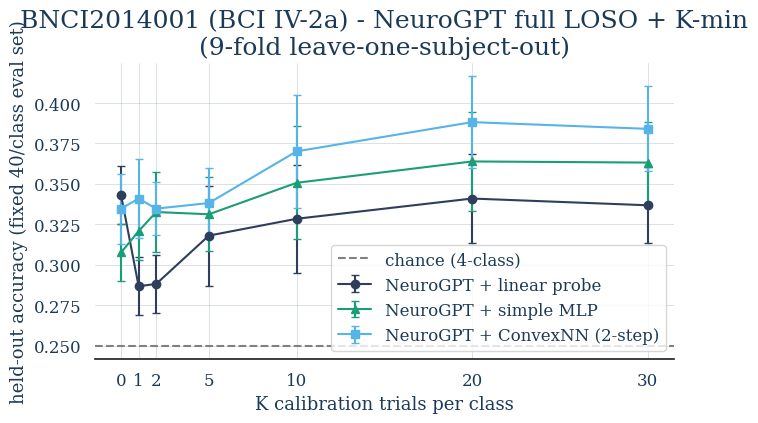

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.4))
for s, lab, mk in [(lin_summary, "linear probe", "o"), (mlp_summary, "simple MLP", "^"), (summary, "ConvexNN (2-step)", "s")]:
    ax.errorbar(s["k"], s["acc_mean"], yerr=s["sem"], marker=mk, capsize=3, label=f"NeuroGPT + {lab}")
ax.axhline(1.0 / N_CLASSES, ls="--", color="grey", label=f"chance ({N_CLASSES}-class)")
ax.set_xlabel("K calibration trials per class")
ax.set_ylabel(f"held-out accuracy (fixed {EVAL_PER_CLASS}/class eval set)")
ax.set_title(f"BNCI2014001 (BCI IV-2a) - NeuroGPT full LOSO + K-min\n({len(SUBJECTS)}-fold leave-one-subject-out)")
ax.set_xticks(list(K_BUDGETS))
ax.legend()
fig.tight_layout()
fig.show()

comparison = lin_summary[["k", "acc_mean", "sem"]].rename(columns={"acc_mean": "linear_acc", "sem": "linear_sem"})
comparison = comparison.merge(mlp_summary[["k", "acc_mean", "sem"]].rename(columns={"acc_mean": "mlp_acc", "sem": "mlp_sem"}), on="k")
comparison = comparison.merge(summary[["k", "acc_mean", "sem"]].rename(columns={"acc_mean": "convex_acc", "sem": "convex_sem"}), on="k")
comparison


## 9. Save artifacts

In [10]:
out_dir = REPO_ROOT / "results" / "neurogpt_bnci2014001_kmin_nb"
out_dir.mkdir(parents=True, exist_ok=True)
stamp = time.strftime("%Y%m%d-%H%M%S")
for name, d in [("linear", lin_df), ("mlp", mlp_df), ("convex", df)]:
    d.to_csv(out_dir / f"{name}_per_split_{stamp}.csv", index=False)
lin_summary.to_csv(out_dir / f"linear_summary_{stamp}.csv", index=False)
mlp_summary.to_csv(out_dir / f"mlp_summary_{stamp}.csv", index=False)
summary.to_csv(out_dir / f"convex_summary_{stamp}.csv", index=False)
comparison.to_csv(out_dir / f"comparison_{stamp}.csv", index=False)
print("wrote:", out_dir)
comparison


wrote: /Users/williamtan/Projects/cs229/etm_clf/results/neurogpt_bnci2014001_kmin_nb


,k,linear_acc,linear_sem,mlp_acc,mlp_sem,convex_acc,convex_sem
0,0,0.343056,0.017935,0.307639,0.017330,0.334722,0.021703
1,1,0.286806,0.018086,0.320833,0.018042,0.340972,0.024675
2,2,0.288194,0.017935,0.332639,0.024995,0.334722,0.016275
3,5,0.318056,0.030944,0.331250,0.022750,0.338194,0.021687
4,10,0.328472,0.033221,0.350694,0.035008,0.370139,0.035059
5,20,0.340972,0.027225,0.363889,0.030383,0.388194,0.028460
6,30,0.336806,0.023603,0.363194,0.025010,0.384028,0.026334
